# ML from DFT data

In [45]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
from importlib.machinery import SourceFileLoader
import re
import sys
from tqdm.notebook import tqdm_notebook
from seaborn import heatmap
import seaborn as sns
from BopFoxFeaturizer.HelperFunctions import get_useful_features
from BopFoxFeaturizer.HelperFunctions import cleanfeaturenames
from BopFoxFeaturizer.HelperFunctions import histoff_realfeatures
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('legend',fontsize=24)
plt.rc('axes',labelsize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)
from BopFoxFeaturizer.FeatureConcatenate import stackdata
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from BopFoxFeaturizer.Featurizer import Featurizer
from BopFoxFeaturizer import HelperFunctions as HF
#stackdata = SourceFileLoader('stackdata','BopFoxFeaturizer/FeatureConcatenate.py').load_module().stackdata
# Original DFT Data
%run SourceDevelopementVersion.py
# which loads Featu
import glob

# Parameters 

In [46]:
CASE = 'INITIAL'  #, 'INITIAL', RELAXED
MODEL = 'ORTHOGONALOS' #, 'ORTHOGONAL', 'CANONICAL','ORTOGONALOS'
CUT_OFF = 'TABLECUTOFF' # 'TABLECUTOFF', 'HISTCUTOFF'
E_MODE ='WUBIND'
C_RITERION = 'test_score'  # test_score, train_score, err
SEARCH_MODE = 'score_only' #score_only, index_too
TARGET = 'EF'
MOMENTS = 10

# Helpeer Functions 

In [47]:
from Tools import CaseNamer, Plotting

In [48]:
FileNames = CaseNamer(
    CASE, MODEL,
    CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE, TARGET=TARGET
)

# Load Features

## Load briefsummary and its features

In [49]:
BS = StructSummaryParser().BriefSummary
Features = Featurizer(BS)

## Load the BOP for the selected case

In [50]:
BOPCOEF_FILE = f'CRCOW_{CASE}_NSC_{MODEL}_{CUT_OFF}_{E_MODE}_{MOMENTS}.pkl'
BopfoxFeatures = pd.read_pickle(BOPCOEF_FILE)
BopfoxFeatures.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
#BopfoxFeatures.drop(columns=['NSC_U_bind'], inplace=True)

## clean features: reduntandly convert all features to float and mean across sites

In [51]:
BopfoxFeatures.dropna(how='any',inplace=True)
M = BopfoxFeatures['NSC_moments'].map(lambda M: np.array(M).mean(axis=0))
S = BopfoxFeatures['NSC_SIGMA'].map(lambda M: np.array(M).mean(axis=0))
Binf=BopfoxFeatures['NSC_Binf'].map(lambda s: [float(si) for si in s]).map(np.mean)
Ainf=BopfoxFeatures['NSC_Ainf'].map(lambda s: [float(si) for si in s]).map(np.mean)
AN = BopfoxFeatures['NSC_an'].map(lambda M: np.array(M).mean(axis=0))
BN = BopfoxFeatures['NSC_bn'].map(lambda M: np.array(M).mean(axis=0))
Mag = Features.MagFeature[BopfoxFeatures.index]
BOP_atom_average = pd.concat([BopfoxFeatures['NSC_U_bind'],M, S, AN, BN, Ainf, Binf, Mag], axis=1)
# Feature Transformation to concatenation
BOP, names = stackdata(BOP_atom_average, BOP_atom_average.columns.values)
BOP = pd.DataFrame(data=BOP, columns=names, index = BOP_atom_average.index)

## define the column names by type of feature

In [52]:
allcolumns = BOP.columns

In [53]:
columns_Mag =BOP.columns[BOP.columns.str.contains('MagConfig')]
columns_U =BOP.columns[BOP.columns.str.contains('U_bind')]
columns_bn = BOP.columns[BOP.columns.str.contains('bn')]
columns_sigma =BOP.columns[BOP.columns.str.contains('SIGMA')] 
columns_moments = BOP.columns[BOP.columns.str.contains('moment')]
columns_an = BOP.columns[BOP.columns.str.contains('an')]

In [54]:
feature_titles = pd.Series(
    HF.cleanfeaturenames([ s.replace('NSC_','').replace('MagConfig_0','MagConfig').replace('bind_0','bind') for s in allcolumns ]), index=allcolumns
)

In [55]:
real_feature = HF.get_useful_features(BOP, allcolumns)

In [56]:
def colsgroup(kind):
    return [ f for f in real_feature if kind in f] 

In [57]:
useful = {f: colsgroup(f) for f in ['an','bn','moment','SIGMA', 'U_bind','MagConfig']}

# Targets

$ \Delta E_F  = \dfrac{1}{N_{atoms}} \left( E_{Total} - \sum _{i} N_i E_i \right) $

In [58]:
groundstates=Features.get_ground_states_energies()
BS['EF'] = Features.get_formation_energy(ground_states_dic=groundstates)
BS = BS.dropna()
DATA = BOP.copy()
DATA[['B0','V0','EF','E0']]=BS[['B0','V0','EF','E0']]

## Distribution of targets

### $E_{F}$

In [59]:
Out_In_First = DATA[~((DATA['EF']>-1) & (DATA['EF']<2))]

In [60]:
DATA = DATA[(DATA['EF'] > -1) & (DATA['EF']< 2)]

### $E_0$

In [61]:
DATA = DATA[(DATA['E0']>-100) & (DATA['E0']<10)]

In [62]:
DATA.shape

(1684, 50)

## B0

In [63]:
DATA = DATA[(DATA['B0'])>0 & (DATA['B0']<500)]

## V0

In [64]:
DATA = DATA[DATA['V0']<50]

In [65]:
DATA.shape

(1681, 50)

## Drop Nans !

In [66]:
DATA.dropna(how='any', axis=0,inplace=True)

# Classification and weighting

Text(0, 0.5, '')

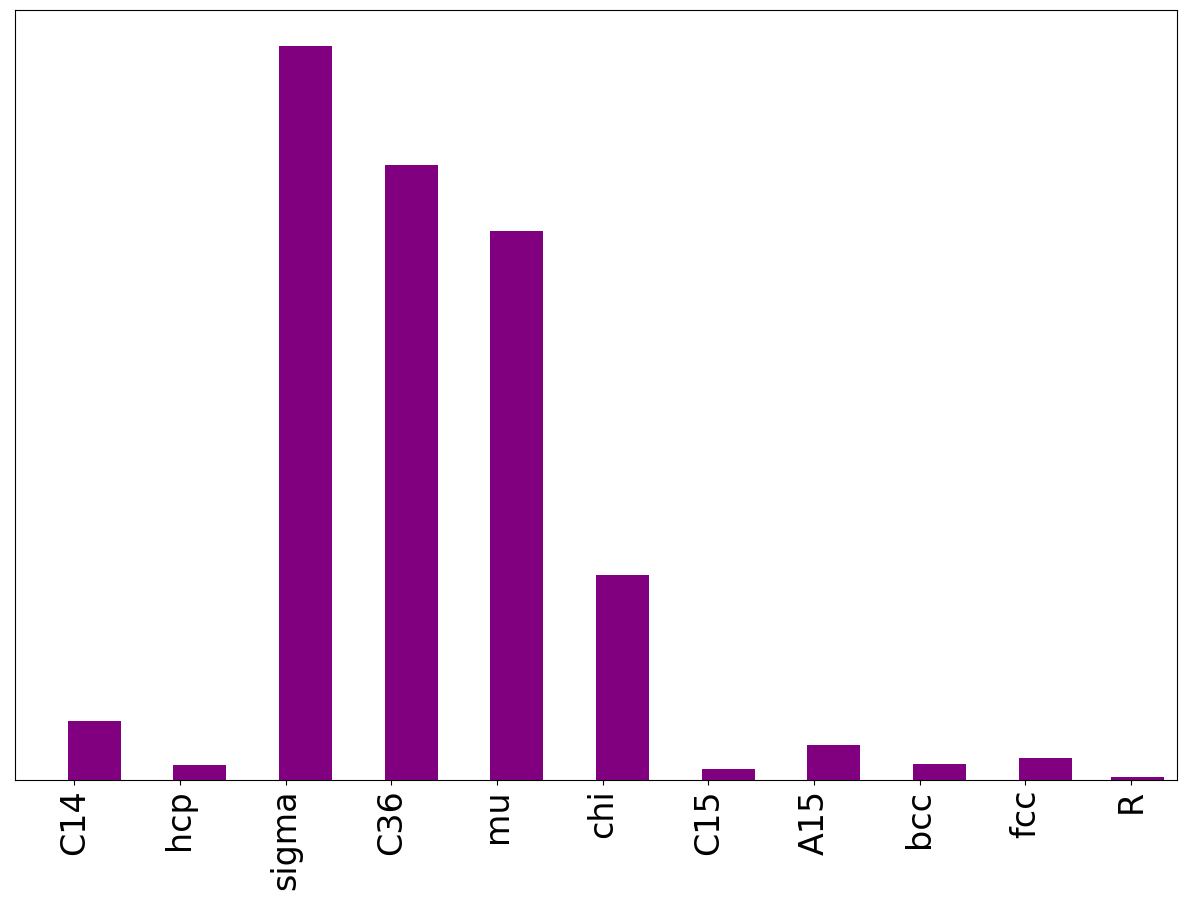

In [67]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
plt.xticks(rotation=90); yticks = plt.yticks([])
plt.ylabel('')

## Class Weights

In [68]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

In [69]:
data_w_classes =pd.concat([DATA,Classes['Class'].loc[DATA.index]], axis=1) 

# Finally some Machine Learning

[![scikit-logo](https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png#background-color:"#FFFFFF")](https://scikit-learn.org/stable/) is a standard tool for machine learning in python. The documentation in their webpage is often a good refference for tutorials, methods and Theory of Machine Learning. 

In [70]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler

## Helper Functions for ML

In [71]:
def plot_the_errors(THISERRORS,thecase):
    alltheclases = np.unique(Classes['Class'])
    thebadclasses = ['hcp', 'bcc', 'fcc','others','delta','R','C15']
    thegoodclases = [c for c in alltheclases if c not in thebadclasses ]
    fig, ax = plt.subplots(len(thegoodclases),1, sharex=True, figsize =(10,2*len(thegoodclases)))
    for i, classes in enumerate(thegoodclases) :
        thiserrors = np.abs(THISERRORS[Classes['Class']==classes])
        e = ax[i].hist (thiserrors, density=False, bins=100, label=classes)
        ax[i].annotate(classes, (0.8,0.5),xycoords = 'axes fraction', fontsize=20)
#    ax[-1].set_xlim([-0.01,1.0])
    ax[-1].set_ylabel('Density Counts',y=4), plt.xlabel('$|  E_F^{predicted} -  E_F^{True} | $')
    fig.tight_layout()
    fig.savefig(FileNames.get_plot_filename('Errors_by_class', thecase))
#    fig.savefig('graphs/Errors_by_class_{}_{}_{}_{}.pdf'.format(case, CASE, MODEL, CUTOFF))
    

def plot_the_prediction_line(theprediction, thepredictionovertest, thecase):
    fig, ax = plt.subplots()
    ax.plot(theprediction, DATA[TARGET],'o', label='full dataset')
    ax.plot(thepredictionovertest, Y_test,'o', label='test set')
    ax.plot(DATA[TARGET], DATA[TARGET],'-k')
    ax.legend()
    ax.set_xlabel('True')# $\Delta E_F$')
    ax.set_ylabel('predicted')# $\Delta E_F$')
    fig.savefig(FileNames.get_plot_filename('Predictionline',thecase))
#    fig.savefig('graphs/predictionline_{}_{}.pdf'.format(themodel,CASE, MODEL, CUTOFF))

def train_test_errors(themodel, Xtrain, Xtest, Ytrain, Ytest):
    Ypredict_train = themodel.predict(Xtrain)
    Ypredict_test = themodel.predict(Xtest)
    return {'train': mean_squared_error(Ytrain, Ypredict_train ,squared=False), 'test':  mean_squared_error(Ytest, Ypredict_test,squared=False )}

def make_simple_pipe(model, with_scaler = True):
        if with_scaler:
            return Pipeline([('scaler',MinMaxScaler()),('regressor', model())])
        else:
            return Pipeline([('regressor', model())])

In [72]:
X_train, X_test, w_train, w_test,  Y_train, Y_test = train_test_split(DATA[real_feature],Classes['Weights'], DATA[TARGET],test_size=0.2, shuffle=True)

I need Lists of errors to compare methods

In [73]:
mses = {}

I also need to remove targets from feature names

## simple regressor - random forest

In [74]:
simple_model = make_simple_pipe(RandomForestRegressor)

In [75]:
simple_model.fit(X_train,Y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('regressor', RandomForestRegressor())])

In [76]:
mses['random forest regressor'] = train_test_errors(simple_model, X_train, X_test,Y_train, Y_test)

In [77]:
mses

{'random forest regressor': {'train': 0.04680499097460959,
  'test': 0.09584111989976454}}

In [78]:
simple_model_noscaler = make_simple_pipe(RandomForestRegressor, with_scaler=False)

In [79]:
simple_model_noscaler.fit(X_train, Y_train)

Pipeline(steps=[('regressor', RandomForestRegressor())])

In [80]:
mses['random forest regressor noscale'] = train_test_errors(simple_model_noscaler, X_train, X_test, Y_train, Y_test)

In [81]:
mses

{'random forest regressor': {'train': 0.04680499097460959,
  'test': 0.09584111989976454},
 'random forest regressor noscale': {'train': 0.04690477076987581,
  'test': 0.09513142249909048}}

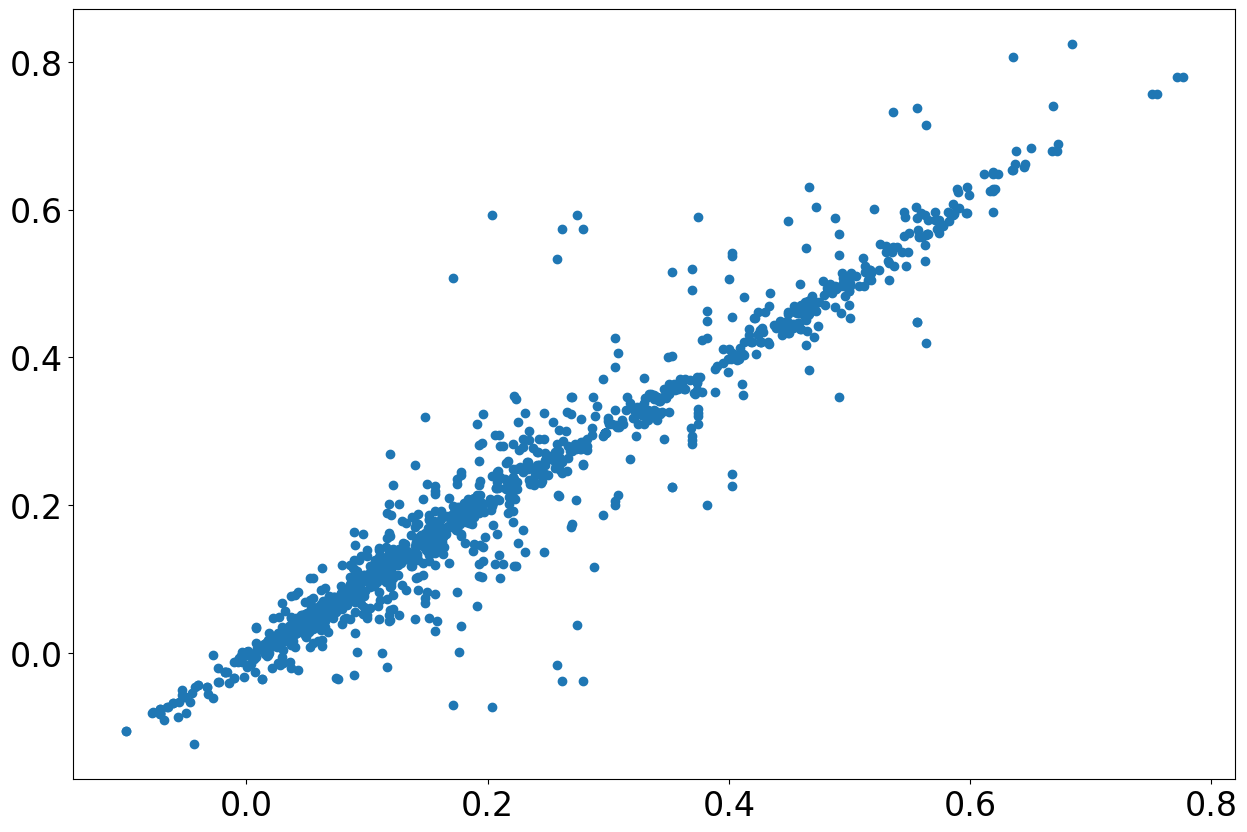

In [82]:
plt.plot(simple_model.predict(X_train),Y_train,'o')
#plt.plot(simple_model_noscaler.predict(X_train),Y_train,'o')

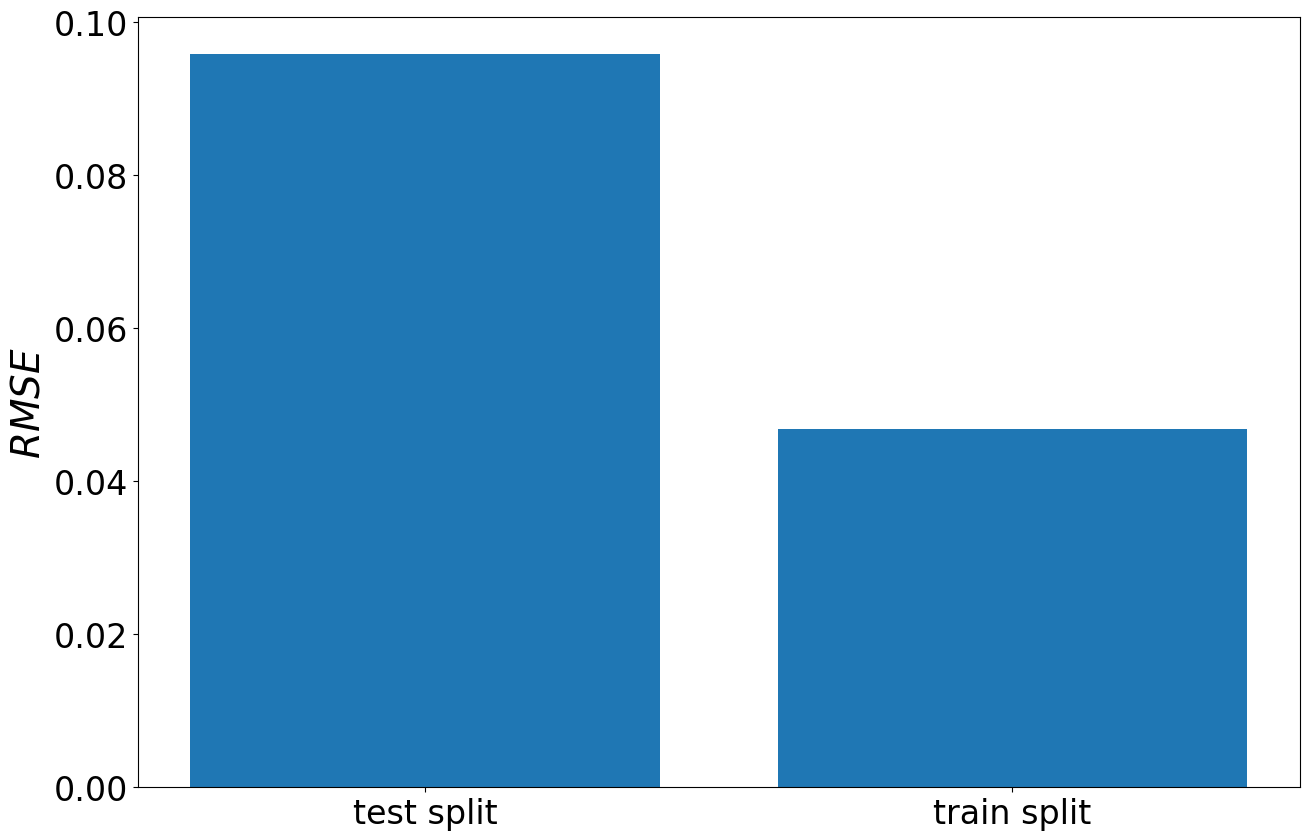

In [83]:
plt.bar(['test split','train split'],[mses['random forest regressor']['test'], mses['random forest regressor']['train']])
label = plt.ylabel('$RMSE$')

In [84]:
YPREDICT = simple_model.predict(DATA[real_feature])
Y_predict_test = simple_model.predict(X_test)
ERRORS = (YPREDICT - DATA[TARGET]).map(np.abs)

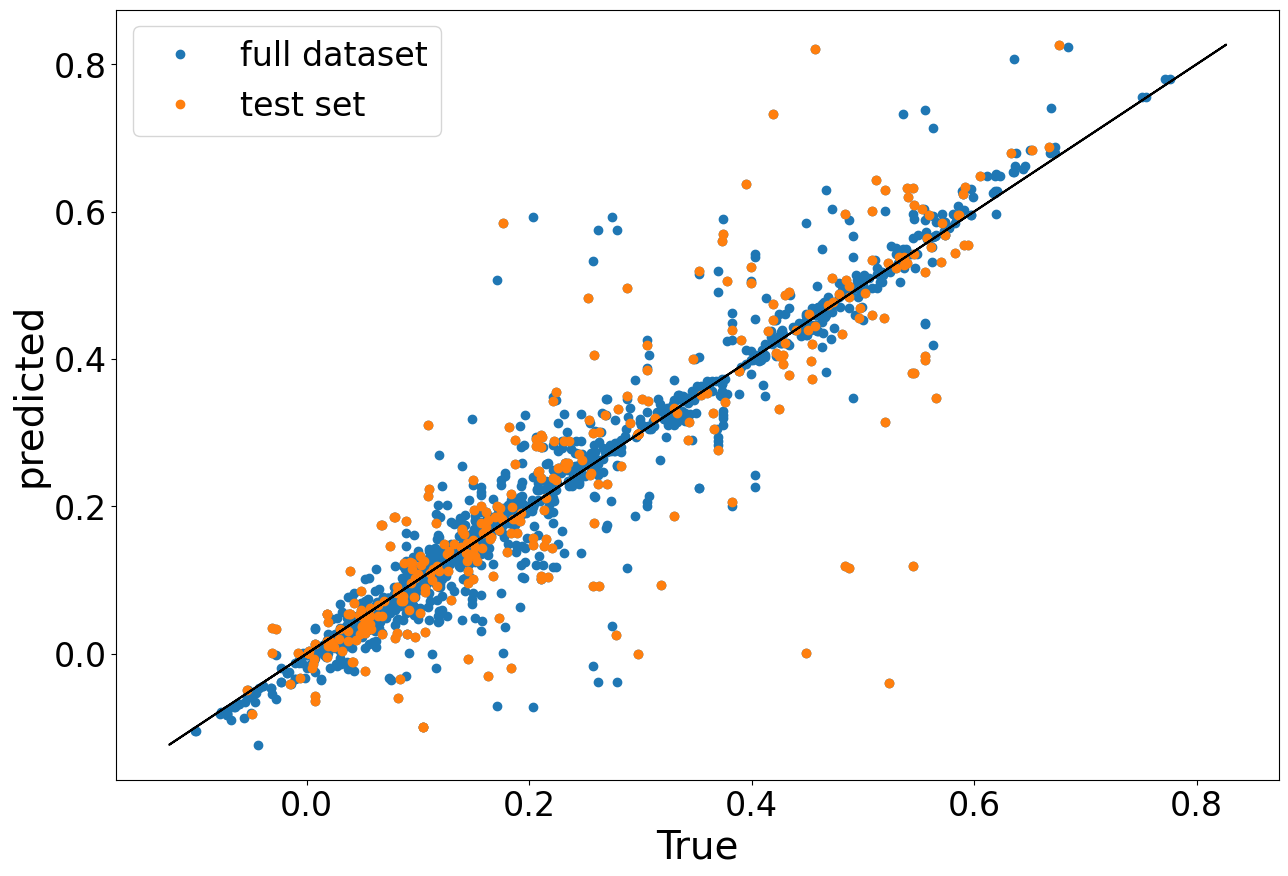

In [85]:
plot_the_prediction_line(YPREDICT, Y_predict_test, 'RandomForestRegressor')

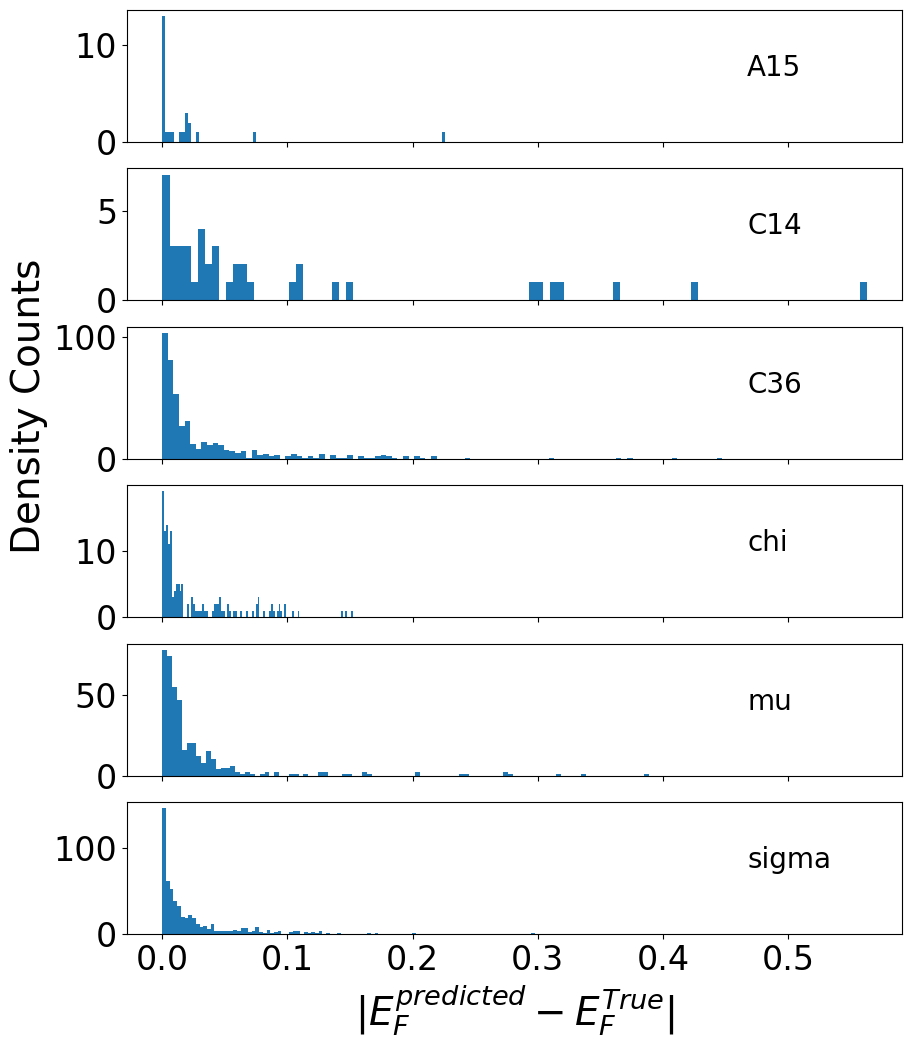

In [86]:
plot_the_errors(ERRORS,'RandomForestRegressor')

In [87]:
ERRORS[ERRORS > 0.35]

index
Co_pv8W_sv16.C36-AABBB.NM     0.363843
Cr_pv6W_sv6.C14-BBA.FM        0.364739
Cr_pv6W_sv6.C14-BBA.NM        0.425525
Cr_pv12W_sv12.C36-BBBAA.NM    0.371809
Co_pv8W_sv4.C14-BAA.NM        0.562837
Co_pv12W_sv12.C36-AAABB.FM    0.408101
Co_pv6W_sv7.mu-BBAAA.NM       0.388795
Co_pv12W_sv12.C36-BBBAA.NM    0.447292
Name: EF, dtype: float64

There is a big variety of regression methods available in scikit-learn package.
[See the documentation](https://scikit-learn.org/stable/supervised_learning.html#supervised-learninghttps://scikit-learn.org/stable/supervised_learning.html#supervised-learning)

# Feature Selection

In [88]:
Bestfeats = {}
Bestscores = {}
FC={}
criterion = 'test_score'

## Random Forest

In [89]:
useful_feature = useful['an']+useful['bn']+useful['moment']+useful['SIGMA']+\
                ['MagConfig_0','NSC_Ainf_0', 'NSC_Binf_0']

In [97]:
# This is the standard way to import modules
del FeatureConcatenate
# from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate

#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
FC['RandomForest'] = FeatureConcatenate(
    #pd.concat([X_train, Y_train['EF']], axis=1), #DATA, 
    DATA[real_feature+[TARGET]],
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=real_feature,
    data_target=TARGET,
    criterion = C_RITERION,
    sort_criteria='score_only'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest'], Bestscores['RandomForest'] = FC['RandomForest'].build_features_list(
    best_feature_proposal=['MagConfig_0'],  #,'NSC_U_bind_0'],
    maxnumfeatures=10,
    pass_force_refit=True,
    report_prefix='RandomForest_'+CASE
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.37it/s]
procesing '['MagConfig_0']' with 'NSC_moments_5' ... ::   0%|                                    | 0/32 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.19138368953575915
Refitting ..


procesing '['MagConfig_0']' with 'NSC_moments_8' ... :: 100%|###########################| 32/32 [00:41<00:00,  1.29s/it]


...

fitting has finished,  test_score  =  0.0902430071188683


procesing '['MagConfig_0', 'NSC_moments_9', 'NSC_moments_0', 'NSC_SIGMA_9', 'NSC_SIGMA_8', 'NSC_SIGMA_1', 'NSC_U_bind_0'

Refitting ..


procesing '['MagConfig_0', 'NSC_moments_9', 'NSC_moments_0', 'NSC_SIGMA_9', 'NSC_SIGMA_8', 'NSC_SIGMA_1', 'NSC_U_bind_0'

fitting has finished,  test_score  =  0.08604397964426413


In [98]:
FileNames = SourceFileLoader('FileNames','Tools.py').load_module().CaseNamer(CASE, MODEL, CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE,TARGET=TARGET)

In [99]:
thisdata = pd.DataFrame(np.array([[x, y] for x, y in zip(Bestfeats['RandomForest'], Bestscores['RandomForest'])]))

In [100]:
thisdata.to_csv(
    FileNames.get_table_filename('BopFeatures_Ubind',FC['RandomForest'].sort_criteria),
    header=False, index=False
)

In [101]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_an'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'an' in f or 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_an'], Bestscores['RandomForest_an'] = \
    FC['RandomForest_an'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_an_'+CASE,
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.41it/s]
procesing '['MagConfig_0']' with 'NSC_bn_5' ... ::   0%|                                         | 0/10 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.18779638784633967
Refitting ..


procesing '['MagConfig_0']' with 'NSC_bn_2' ... :: 100%|################################| 10/10 [00:11<00:00,  1.15s/it]


fitting has finished,  test_score  =  0.11402280481492093


procesing '['MagConfig_0', 'NSC_bn_5']' with 'NSC_an_2' ... ::   0%|                              | 0/5 [00:00<?, ?it/s]

Refitting ..


procesing '['MagConfig_0', 'NSC_bn_5']' with 'NSC_an_3' ... :: 100%|######################| 5/5 [00:07<00:00,  1.40s/it]


fitting has finished,  test_score  =  0.10139636084630904


In [102]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_bn'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_bn'], Bestscores['RandomForest_bn'] = FC['RandomForest_bn'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_bn_'+CASE,
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.44it/s]
procesing '['MagConfig_0']' with 'NSC_bn_5' ... ::   0%|                                          | 0/5 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.18776051662729978
Refitting ..


procesing '['MagConfig_0']' with 'NSC_bn_2' ... :: 100%|##################################| 5/5 [00:05<00:00,  1.16s/it]


fitting has finished,  test_score  =  0.11436573435336986


In [103]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_sigma'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'SIGMA' in f],
    data_target=TARGET,
    criterion = criterion, sort_criteria='index_too'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_sigma'], Bestscores['RandomForest_sigma'] = FC['RandomForest_sigma'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_sigma_'+CASE,
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.43it/s]
procesing '['MagConfig_0']' with 'NSC_SIGMA_3' ... ::   0%|                                       | 0/9 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.18780570017782267
Refitting ..


procesing '['MagConfig_0']' with 'NSC_SIGMA_9' ... :: 100%|###############################| 9/9 [00:10<00:00,  1.18s/it]
procesing '['MagConfig_0', 'NSC_SIGMA_5']' with 'NSC_SIGMA_3' ... ::   0%|                        | 0/7 [00:00<?, ?it/s]

...

Refitting ..


procesing '['MagConfig_0', 'NSC_SIGMA_5', 'NSC_SIGMA_1', 'NSC_SIGMA_2']' with 'NSC_SIGMA_9' ... :: 100%|#| 2/2 [00:03<00
procesing '['MagConfig_0', 'NSC_SIGMA_5', 'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_3']' with 'NSC_SIGMA_9' ... ::   0%| 

fitting has finished,  test_score  =  0.1191616123009749
Refitting ..


procesing '['MagConfig_0', 'NSC_SIGMA_5', 'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_3']' with 'NSC_SIGMA_9' ... :: 100%|#

fitting has finished,  test_score  =  0.11256231695097195


In [104]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_moments'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'moments' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_moments'], Bestscores['RandomForest_moments'] = FC['RandomForest_moments'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_moments_'+CASE,
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.42it/s]
procesing '['MagConfig_0']' with 'NSC_moments_3' ... ::   0%|                                    | 0/10 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.18791522552668566
Refitting ..


procesing '['MagConfig_0']' with 'NSC_moments_4' ... :: 100%|###########################| 10/10 [00:11<00:00,  1.15s/it]


fitting has finished,  test_score  =  0.1363998153711789


procesing '['MagConfig_0', 'NSC_moments_9']' with 'NSC_moments_6' ... ::   0%|                    | 0/5 [00:00<?, ?it/s]

Refitting ..


procesing '['MagConfig_0', 'NSC_moments_9']' with 'NSC_moments_4' ... :: 100%|############| 5/5 [00:06<00:00,  1.39s/it]


fitting has finished,  test_score  =  0.09529035651465027


In [120]:
def plot_learning_curve(thescores, thefeatures, ax=None, modelname='RandomForest',dothelabels = True):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(np.arange(1,len(thescores)+1),thescores) 
    ax.set_ylabel ("RMSE "+C_RITERION)
    ax.set_xlabel ("number of features")
    if dothelabels:
        for i, feat in enumerate(thefeatures):
            t = plt.annotate(
                feature_titles[feat],
                ((i+1), thescores[i]),
                ((i+1), thescores[i]),
                fontsize=22,
            )
            t.set_bbox(dict(facecolor='white', alpha=0.5))

    plt.savefig(FileNames.get_plot_filename('LearningCurve', modelname))
    return ax

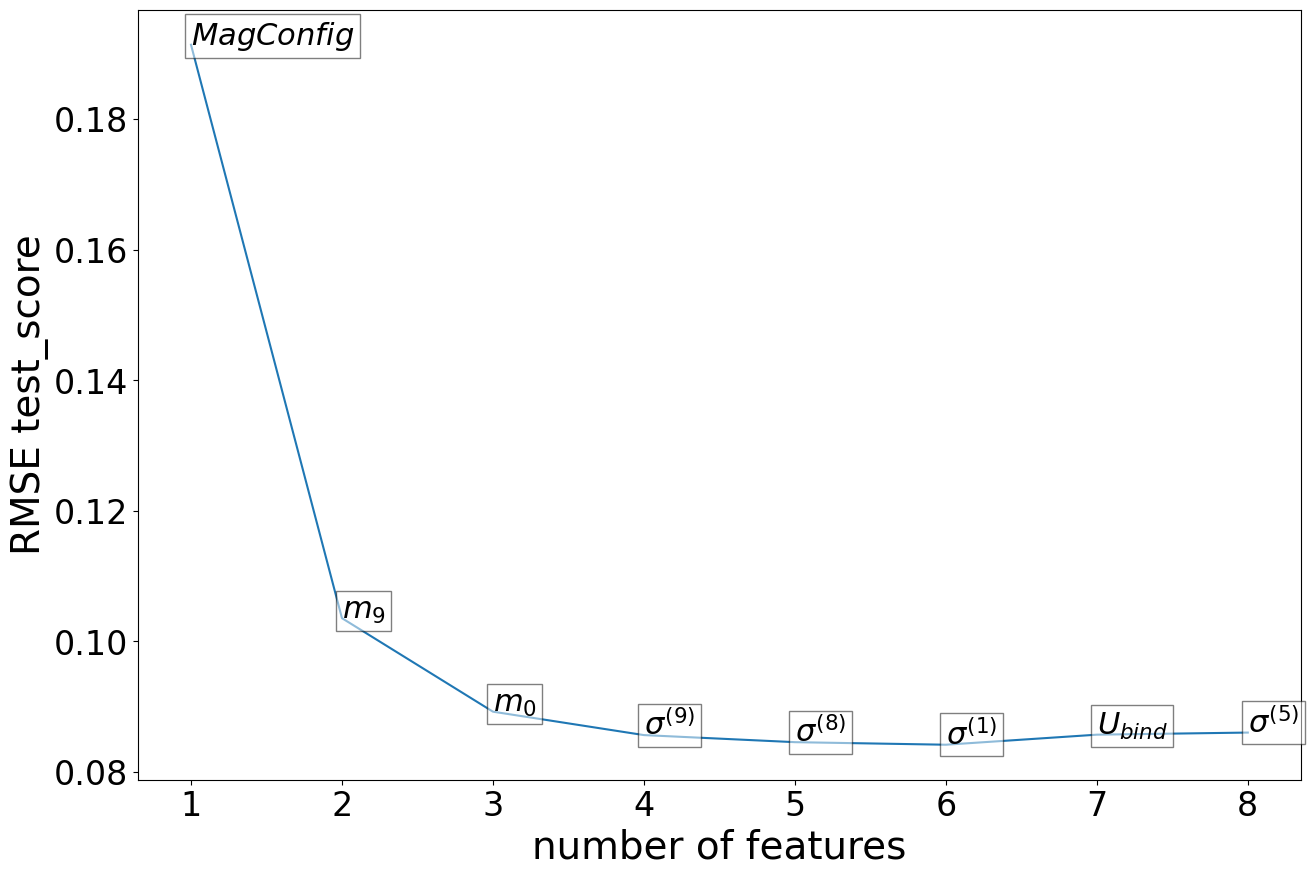

In [122]:
ax1 = plot_learning_curve(Bestscores['RandomForest'],Bestfeats['RandomForest'])
#ax2 = plot_learning_curve(Bestscores['RandomForest_an'],Bestfeats['RandomForest_an'], ax=ax1)
#ax2 = plot_learning_curve(Bestscores['RandomForest_moments'],Bestfeats['RandomForest_moments'], ax=ax1)

In [123]:
feature_titles = feature_titles[feature_titles  != '']

# The Errors

In [124]:
YPREDICT = FC['RandomForest'].report['best_estimator'].iloc[-1].predict(DATA[Bestfeats['RandomForest']])
EPREDICT = np.abs(YPREDICT - DATA[TARGET])

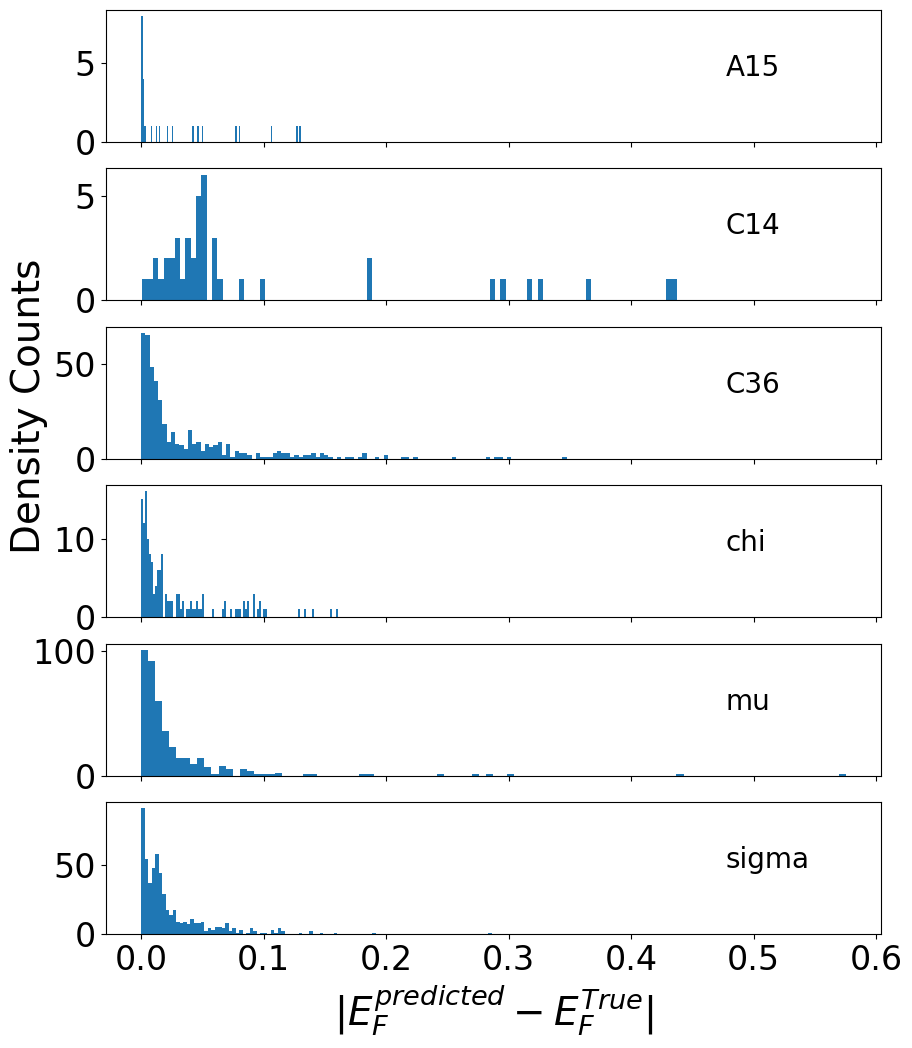

In [125]:
plot_the_errors(EPREDICT,'FeatureSelectionRandomForest')

# incremental simple model

In [126]:
def incremental_learn (columnsgroup):
    incremental_score = [] 
    progress = tqdm_notebook(range(0,len(columnsgroup)))
    for max_index in progress:
        incremental_model = RandomForestRegressor()
        all_features = np.hstack((['MagConfig_0','NSC_U_bind_0'], np.ravel(columnsgroup[:max_index])))#  + list(columns_bn[:max_index])
        feature_group = all_features
        this_feature_list = feature_group
        THHEX =DATA[feature_group].loc[X_train.index]
        incremental_model.fit(THHEX , Y_train)
        Ytrain_predict = incremental_model.predict(THHEX)
        Ytest_predict = incremental_model.predict(DATA[feature_group].loc[X_test.index])
        incremental_score.append(mean_squared_error(Y_test, Ytest_predict, squared=False))
    return incremental_score

In [127]:
cols_an_bn = [[an, bn] for an, bn in zip(columns_an, columns_bn) ]

In [128]:
incremental_score_moments = incremental_learn(columns_moments)
np.savetxt(FileNames.get_table_filename('incremental_score','moments'),incremental_score_moments)

  0%|          | 0/10 [00:00<?, ?it/s]

In [129]:
incremental_score_an = incremental_learn(cols_an_bn)
np.savetxt(FileNames.get_table_filename('incremental_score','an'),incremental_score_an)

  0%|          | 0/11 [00:00<?, ?it/s]

In [130]:
incremental_score_sigmas = incremental_learn(columns_sigma)
np.savetxt(FileNames.get_table_filename('incremental_score','sigmas'),incremental_score_sigmas)

  0%|          | 0/10 [00:00<?, ?it/s]

In [131]:
from matplotlib.ticker import FormatStrFormatter

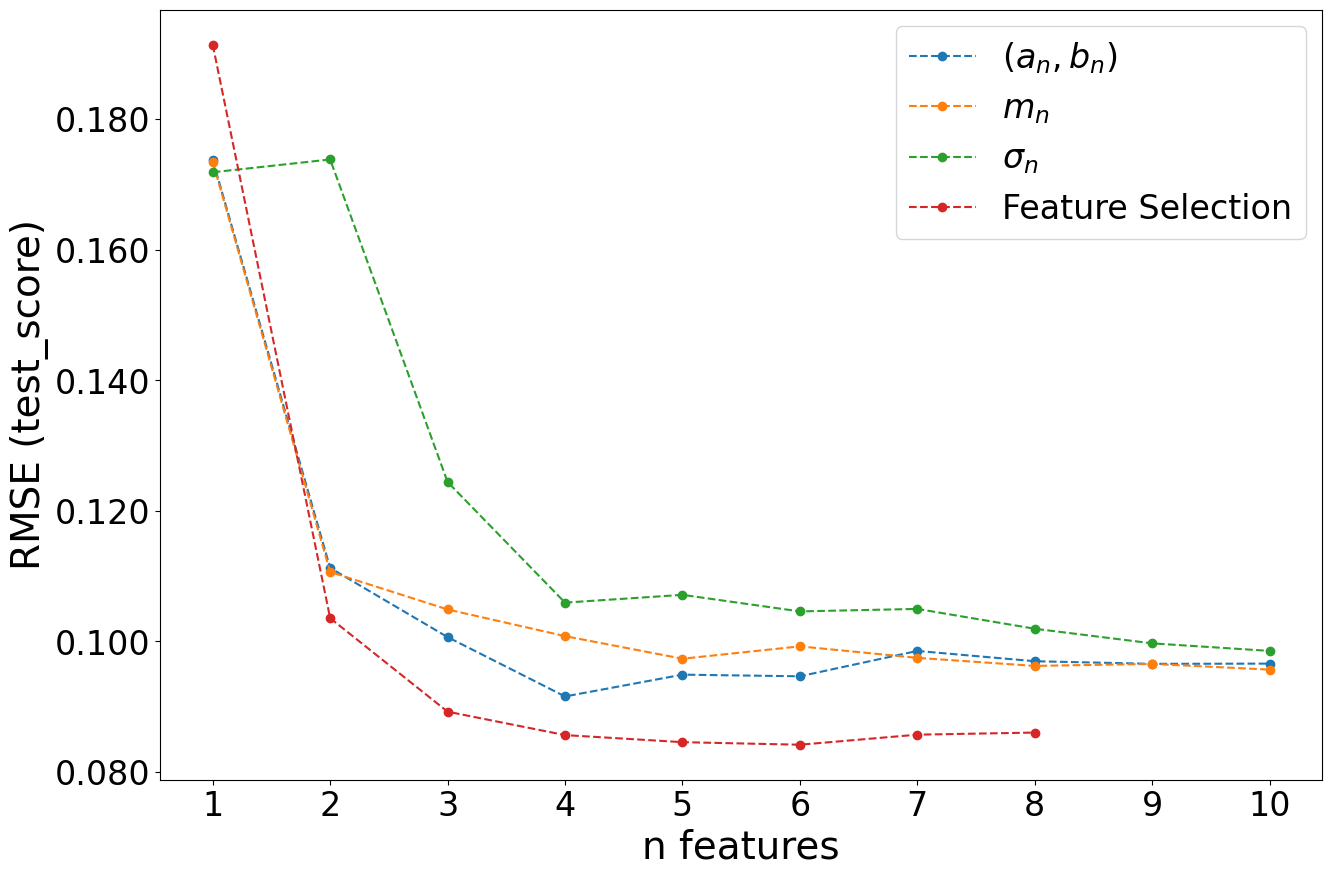

In [132]:
thex = np.linspace(1,len(incremental_score_moments), len(incremental_score_moments))
fig, ax = plt.subplots()
ax.plot(thex, incremental_score_an[:-1],'--o', label = ('$(a_n,b_n)$'))
ax.plot(thex , incremental_score_moments,'--o', label ='$m_n$')
ax.plot(thex, incremental_score_sigmas,'--o', label = '$\sigma _n$')
ax.plot(thex[:len(Bestscores['RandomForest'])], Bestscores['RandomForest'], '--o', label = 'Feature Selection')
ax.legend()
ax.set_xlabel('n features')
ax.tick_params(axis='y',)
ax.set_xticks(thex)
ax.yaxis.set_major_formatter(FormatStrFormatter('%0.3f'))
ax.set_ylabel(f'RMSE ({criterion})')
#ax.set_ylim([0.05,0.07])
fig.savefig(FileNames.get_plot_filename('OrthogonalFeatures','1stMagconfig'))

# Model Usage

In [133]:
BestDecisionTree = FC['RandomForest'].report['best_estimator'][-1]

The model was already fitted, don need to fit again, just use it to predict !

In [134]:
best_Y_train_predict = BestDecisionTree.predict(X_train[Bestfeats['RandomForest']])
best_Y_test_predict = BestDecisionTree.predict(X_test[Bestfeats['RandomForest']])

In [135]:
YPREDICT = BestDecisionTree.predict(DATA[Bestfeats['RandomForest']])

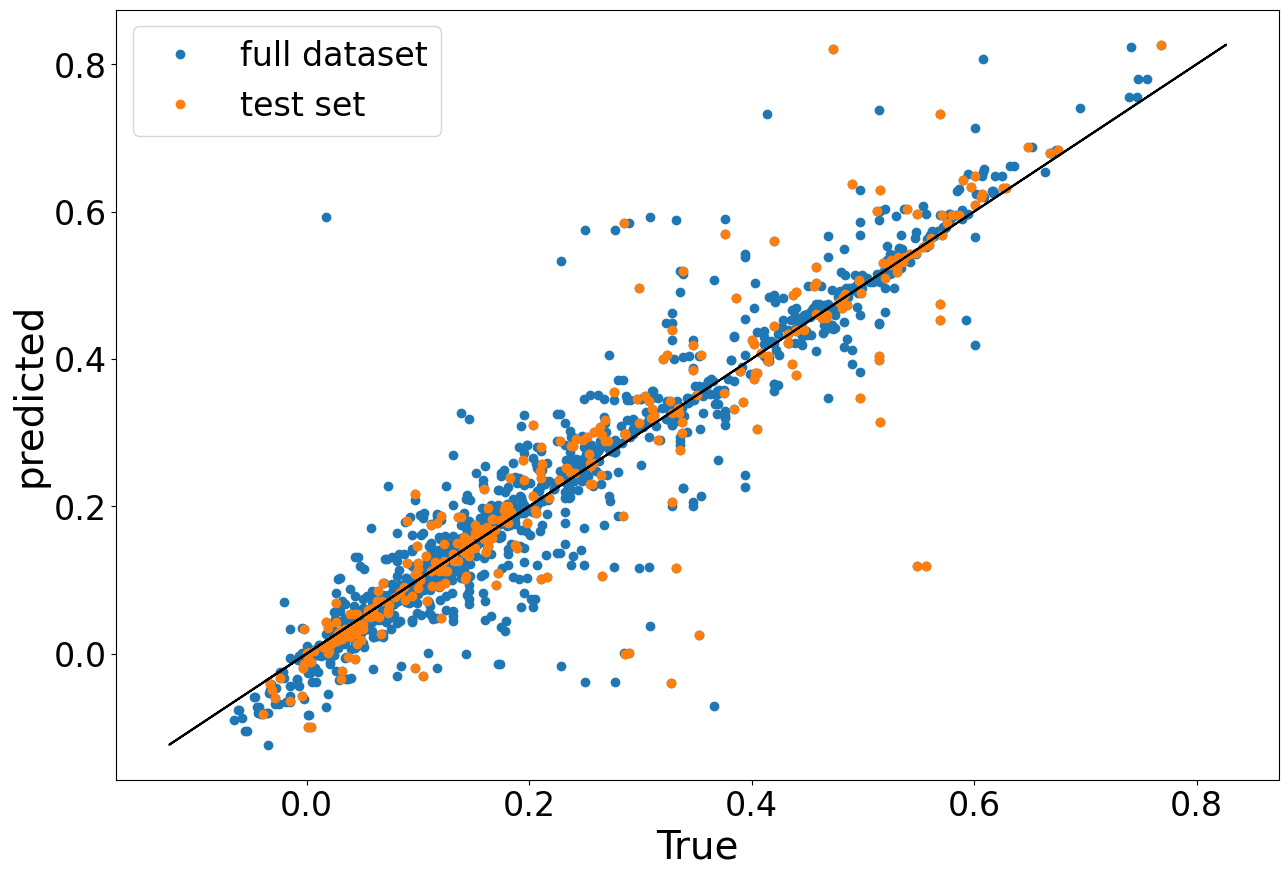

In [136]:
plot_the_prediction_line(YPREDICT,best_Y_test_predict,'BestRandomForest')